In [2]:
# ── IMPORTS ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100


In [14]:
# ── A1. Load + audit ─────────────────────────────────────────────────
import os

CSV_PATH = "../data/oil_well.csv"
XLSX_PATH = "../data/oil_well.xlsx"

if os.path.exists(XLSX_PATH):
    raw = pd.read_excel(XLSX_PATH, header=None)
elif os.path.exists(CSV_PATH):
    raw = pd.read_csv(CSV_PATH, header=None)
else:
    raise FileNotFoundError("Put oil_well.csv or oil_well.xlsx in ../data/ first")

header_row_idx = 0
for i in range(min(10, len(raw))):
    row_values = raw.iloc[i].astype(str).str.strip()
    if row_values.eq("Date").any():
        header_row_idx = i
        break

df = raw.iloc[header_row_idx + 1:].copy()
df.columns = [str(c).strip() for c in raw.iloc[header_row_idx]]
df = df.reset_index(drop=True)

for c in df.columns:
    if c != "Date":
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


Shape: (2939, 9)

Columns: ['Date', 'Oil volume (m3/day)', 'Volume of liquid (m3/day)', 'Gas volume (m3/day)', 'Water volume (m3/day)', 'Water cut (%)', 'Working hours', 'Dynamic level (m)', 'Reservoir pressure (atm)']

Dtypes:
 Date                         object
Oil volume (m3/day)           int64
Volume of liquid (m3/day)     int64
Gas volume (m3/day)           int64
Water volume (m3/day)         int64
Water cut (%)                 int64
Working hours                 int64
Dynamic level (m)             int64
Reservoir pressure (atm)      int64
dtype: object

Missing values:
 Date                         0
Oil volume (m3/day)          0
Volume of liquid (m3/day)    0
Gas volume (m3/day)          0
Water volume (m3/day)        0
Water cut (%)                0
Working hours                0
Dynamic level (m)            0
Reservoir pressure (atm)     0
dtype: int64

Duplicate rows: 0


,Date,Oil volume (m3/day),Volume of liquid (m3/day),Gas volume (m3/day),Water volume (m3/day),Water cut (%),Working hours,Dynamic level (m),Reservoir pressure (atm)
0,2013-01-01 00:00:00,49,70,13055,21,29,24,1819,214
1,2013-01-02 00:00:00,49,70,13055,21,29,24,1836,214
2,2013-01-03 00:00:00,49,70,13055,21,29,24,1788,214
3,2013-01-04 00:00:00,49,70,13055,21,29,24,1789,214
4,2013-01-05 00:00:00,44,70,11768,26,36,24,1825,214


In [15]:
# Target: daily oil production volume — the natural regression target for this dataset.
TARGET_COLUMN = "Oil volume (m3/day)"

assert TARGET_COLUMN in df.columns, f"'{TARGET_COLUMN}' not found — check df.columns above and fix TARGET_COLUMN"
print(df[TARGET_COLUMN].describe())


count    2939.000000
mean       17.624362
std         9.689026
min         0.000000
25%        11.000000
50%        15.000000
75%        22.000000
max        49.000000
Name: Oil volume (m3/day), dtype: float64


In [20]:
#Convert the date into useful numeric features like year and month, then remove the original date column
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day_of_year"] = df["Date"].dt.dayofyear
    df = df.drop(columns=["Date"])
    print("Parsed Date -> year, month, day_of_year; dropped raw Date column")


Parsed Date -> year, month, day_of_year; dropped raw Date column


### **EDA visualisations + insight commentary**

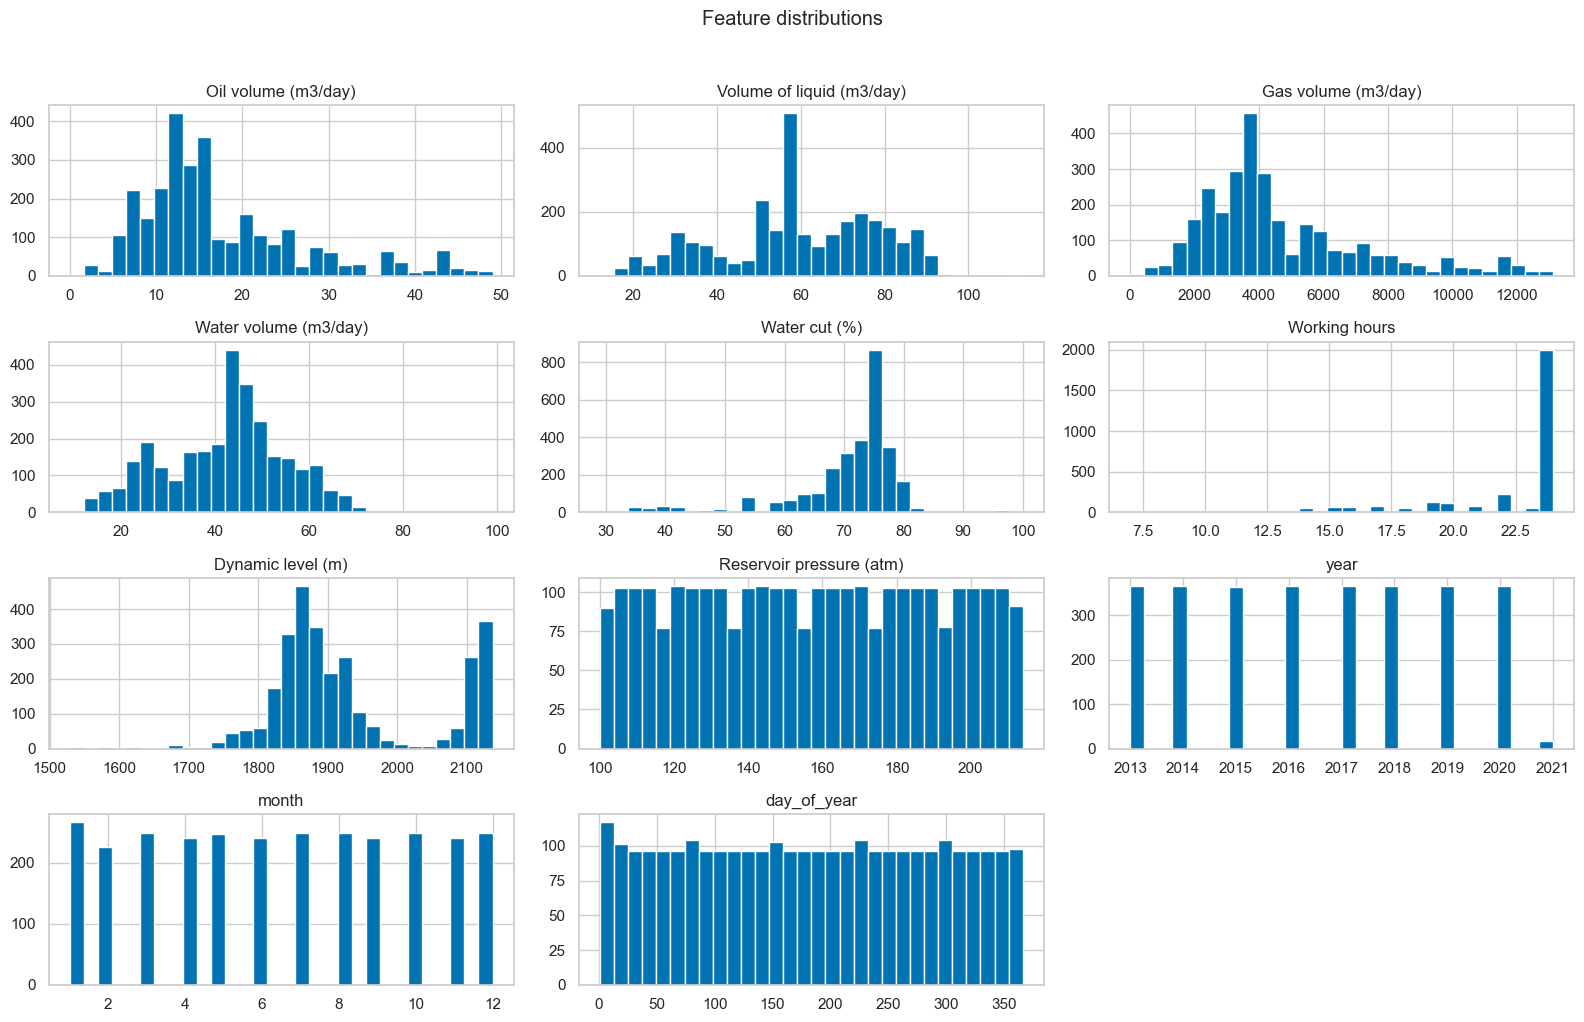

In [11]:
# Distribution plots for numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(bins=30, figsize=(16, 10))
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.savefig("../models/eda_distributions.png", bbox_inches="tight")
plt.show()


**Observation:** *note any skewed features, obvious outlier ranges, or unexpected spikes here.*

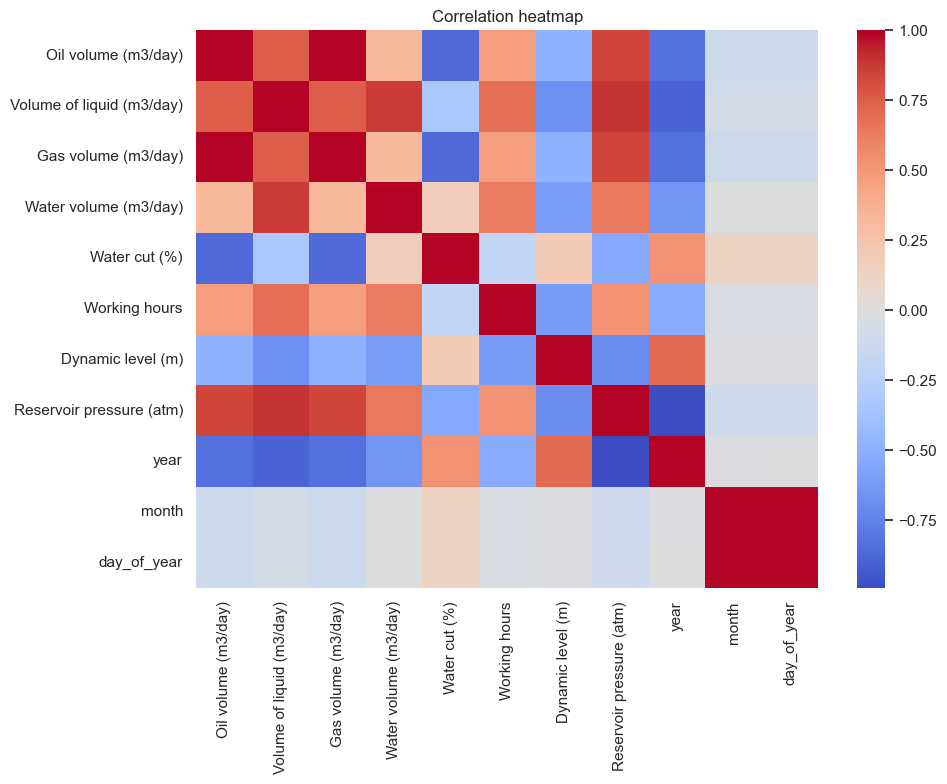

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../models/eda_correlation.png", bbox_inches="tight")
plt.show()


**Observation:** *note which features correlate most strongly with `TARGET_COLUMN`, and any multicollinearity between predictors.*

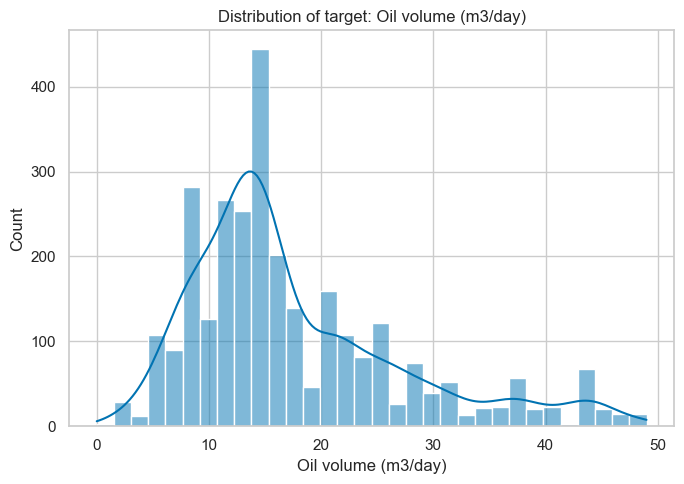

In [16]:
# Target distribution
plt.figure(figsize=(7, 5))
sns.histplot(df[TARGET_COLUMN], kde=True)
plt.title(f"Distribution of target: {TARGET_COLUMN}")
plt.tight_layout()
plt.savefig("../models/eda_target_dist.png", bbox_inches="tight")
plt.show()


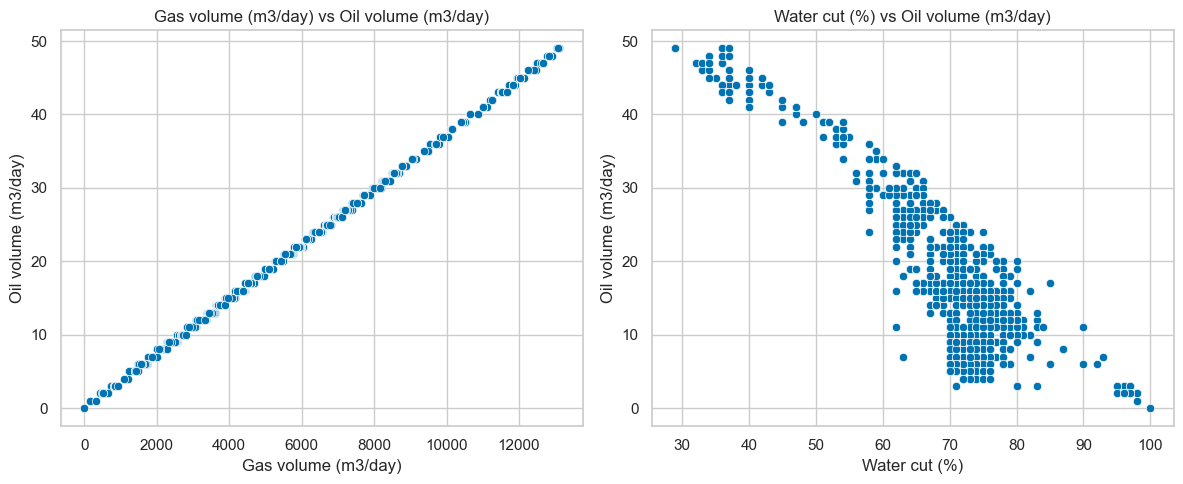

In [18]:
#  two scatter plots: feature vs target
top_corr_features = corr[TARGET_COLUMN].abs().sort_values(ascending=False).index[1:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, top_corr_features):
    sns.scatterplot(data=df, x=feat, y=TARGET_COLUMN, ax=ax)
    ax.set_title(f"{feat} vs {TARGET_COLUMN}")
plt.tight_layout()
plt.savefig("../models/eda_scatter.png", bbox_inches="tight")
plt.show()


**Observation:** *describe the relationship shape (linear/non-linear/none) you see for these two features.*

###  **Cleaning: missing values, duplicates, outliers**

In [21]:
# Missing values: numeric -> median, categorical -> mode (justified: robust to outliers/skew)
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

# Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

assert df.isnull().sum().sum() == 0, "Still missing values — check columns above"


Dropped 0 duplicate rows


In [22]:
# IQR outlier check + capping on numeric columns (excluding target so we don't distort it blindly)
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_report = {}
for c in [x for x in num_cols if x != TARGET_COLUMN]:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_report[c] = n_out
    if n_out > 0:
        df[c] = df[c].clip(lo, hi)  # cap rather than drop, to preserve sample size

pd.Series(outlier_report, name="outliers_capped").sort_values(ascending=False)


Working hours                357
Water cut (%)                312
Gas volume (m3/day)          178
Water volume (m3/day)         13
Dynamic level (m)             13
Volume of liquid (m3/day)      2
Reservoir pressure (atm)       0
year                           0
month                          0
day_of_year                    0
Name: outliers_capped, dtype: int64

**Justification:** capping (winsorising) at the 1.5×IQR fences is used instead of dropping rows, so genuine but extreme readings are retained without letting a handful of rows dominate scale-sensitive models like SVR/KNN.

###  **Feature engineering**

In [23]:
# Create a meaningful feature to capture relationships between variables.
numeric_predictors = [c for c in num_cols if c != TARGET_COLUMN]
if len(numeric_predictors) >= 2:
    a, b = numeric_predictors[0], numeric_predictors[1]
    df[f"{a}_per_{b}"] = df[a] / df[b].replace(0, np.nan)
    df[f"{a}_per_{b}"] = df[f"{a}_per_{b}"].fillna(df[f"{a}_per_{b}"].median())
    print(f"Engineered feature added: {a}_per_{b}")


Engineered feature added: Volume of liquid (m3/day)_per_Gas volume (m3/day)


**Justification:** This ratio feature helps compare production relative to well depth, making the data more meaningful than using raw values alone.

### **Encoding, scaling, splitting**

In [24]:
# Encode categoricals: one-hot for nominal columns
cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != TARGET_COLUMN]
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True) if cat_cols else df.copy()

X = df_enc.drop(columns=[TARGET_COLUMN])
y = df_enc[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)


Train: (2351, 11) Test: (588, 11)


###  **10 regression algorithms + comparison table**

Each model follows the same 4-line pattern: instantiate → fit → predict → score.
Results are collected into one summary table, ranked by R².


In [25]:
results = []
all_regression_models = {}   # name -> fitted model/pipeline, saved so the GUI can query any of them

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2 = r2_score(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    mae = mean_absolute_error(y_te, pred)
    results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
    all_regression_models[name] = model
    print(f"{name:28s} R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return model


In [26]:
# 1. Linear Regression — baseline; interpret coefficients
lin = evaluate("Linear Regression", LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)


Linear Regression            R2=0.9970  RMSE=0.5285  MAE=0.3719


In [27]:
# 2. Ridge Regression — L2 regularisation
ridge = evaluate("Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


Ridge Regression             R2=0.9969  RMSE=0.5428  MAE=0.3793


In [28]:
# 3. Lasso Regression — L1 regularisation; watch for feature sparsity
lasso = evaluate("Lasso Regression", Lasso(alpha=0.01, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)
print("Non-zero coefficients:", np.sum(lasso.coef_ != 0), "/", len(lasso.coef_))


Lasso Regression             R2=0.9965  RMSE=0.5701  MAE=0.3867
Non-zero coefficients: 9 / 11


In [29]:
# 4. ElasticNet Regression — combined L1 + L2
enet = evaluate("ElasticNet Regression", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


ElasticNet Regression        R2=0.9954  RMSE=0.6577  MAE=0.4405


In [31]:
#Polynomial Regression fits a curved relationship between the input features and target by using different polynomial degrees.from sklearn.pipeline import Pipeline

for deg in [2, 3]:
    poly_pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression()),
    ])
    evaluate(f"Polynomial Regression (deg={deg})", poly_pipeline, X_train_scaled, X_test_scaled, y_train, y_test)


Polynomial Regression (deg=2) R2=0.9993  RMSE=0.2594  MAE=0.1977
Polynomial Regression (deg=3) R2=0.9854  RMSE=1.1722  MAE=0.2374
